In [1]:
!pip install joblib -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn: Pipeline, Preprocessing, Models, Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

# Model export
import joblib

# Suppress minor warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') #update path according to your system 

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows")
df.head()

# Basic dataset overview
print("Column Data Types & Non-Null Counts")
df.info()

print("\nStatistical Summary (Numeric Columns)")
df.describe()

Dataset loaded successfully!
Shape: 7043 rows × 21 columns

First 5 rows
Column Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
# Exploratory Data Analysis(EDA)
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found:")
    print(missing)

# NOTE: TotalCharges column has blank spaces (' ') that look like data
# but are actually missing — we'll handle this in preprocessing.
print(f"\nBlank entries in TotalCharges: {(df['TotalCharges'] == ' ').sum()}")

No missing values found in the dataset.

Blank entries in TotalCharges: 11


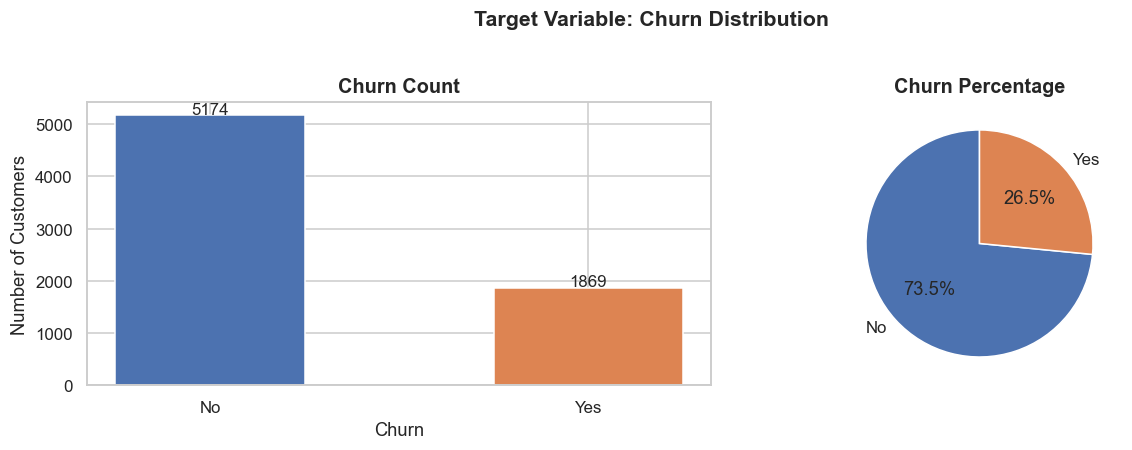

Non-Churn : 5174  (73.5%)
Churn     : 1869  (26.5%)

 Dataset is imbalanced  more non churners than churners.
This is normal for churn datasets.We will use F1 score alongside accuracy.


In [4]:
# Visualization 1: Churn Class Distribution
# This tells us if the dataset is imbalanced (more non-churners than churners)

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Non-Churn : {churn_counts['No']}  ({churn_pct['No']:.1f}%)")
print(f"Churn     : {churn_counts['Yes']}  ({churn_pct['Yes']:.1f}%)")
print("\n Dataset is imbalanced  more non churners than churners.")
print("This is normal for churn datasets.We will use F1 score alongside accuracy.")

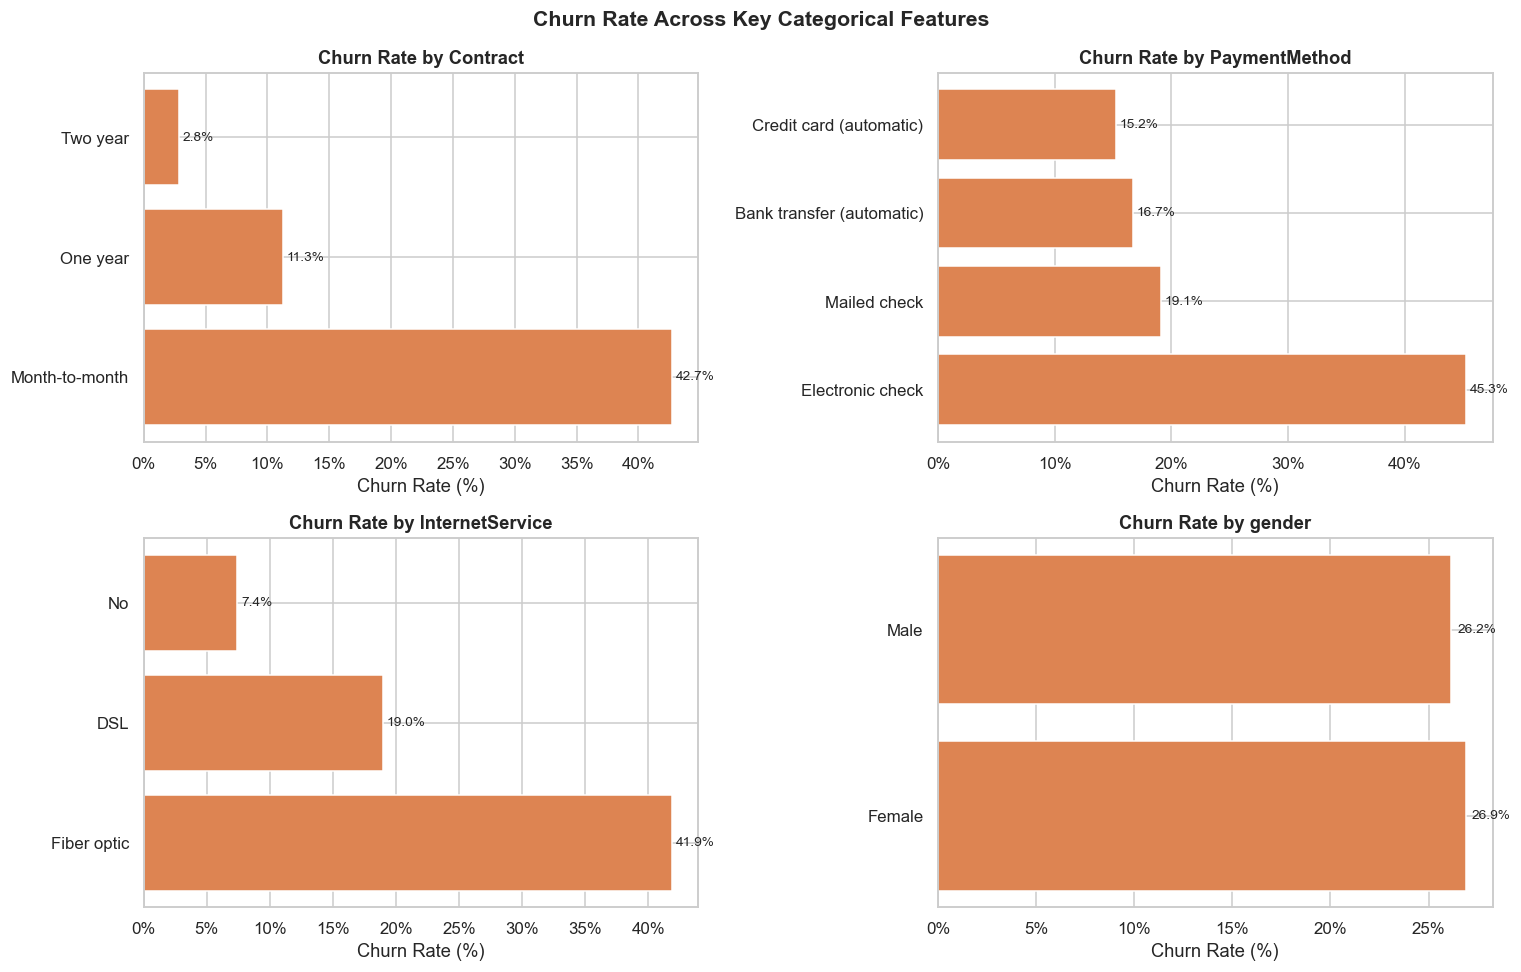

In [5]:
# Visualization 2: Churn vs Key Categorical Features
# We look at how churn varies across contract type, payment method, etc.

cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [feature, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].barh(churn_rate[feature], churn_rate['ChurnRate'],
                         color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn Rate (%)')
    axes[i].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Churn Rate Across Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

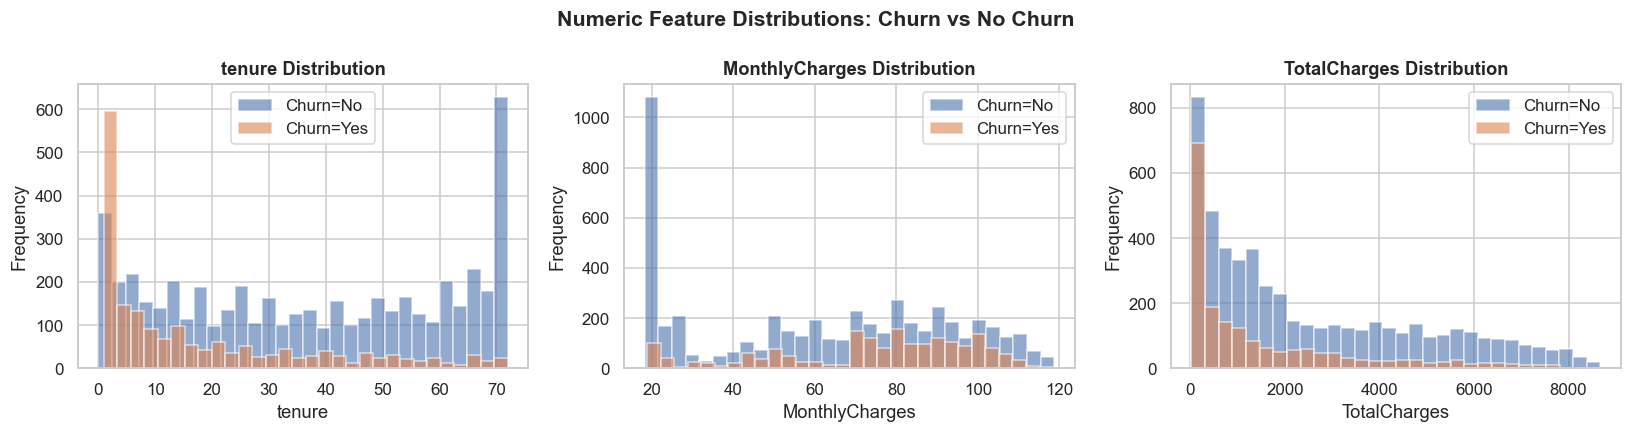

Key Observation: Customers with LOW tenure and HIGH monthly charges tend to churn more.


In [6]:
# Visualization 3: Numeric Feature Distributions by Churn
# How do tenure, monthly charges, and total charges differ between churners?

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# TotalCharges needs to be numeric for this plot
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(num_features):
    for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
        subset = df_plot[df_plot['Churn'] == label][feature].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color)
    axes[i].set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions: Churn vs No Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Observation: Customers with LOW tenure and HIGH monthly charges tend to churn more.")

In [7]:
# Step 1: Drop customerID, it's just an identifier, not a predictor
df.drop('customerID', axis=1, inplace=True)
print("Dropped 'customerID' column")

# Step 2: Fix TotalCharges  blank strings converted to NaN, then numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_count = df['TotalCharges'].isnull().sum()
print(f" Converted TotalCharges to numeric | {blank_count} NaN values found (will be imputed in pipeline)")

# Step 3: Encode target variable (Churn: Yes=1, No=0)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f" Target encoded | Churn=1: {df['Churn'].sum()} | Churn=0: {(df['Churn']==0).sum()}")

# Step 4: Encode all remaining categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

label_encoders = {}   # Store encoders in case we need to inverse transform later
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print(f"\n All {len(categorical_cols)} categorical columns encoded")
print("\n Processed Dataset (first 5 rows)")
df.head()

Dropped 'customerID' column
 Converted TotalCharges to numeric | 11 NaN values found (will be imputed in pipeline)
 Target encoded | Churn=1: 1869 | Churn=0: 5174

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

 All 15 categorical columns encoded

 Processed Dataset (first 5 rows)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


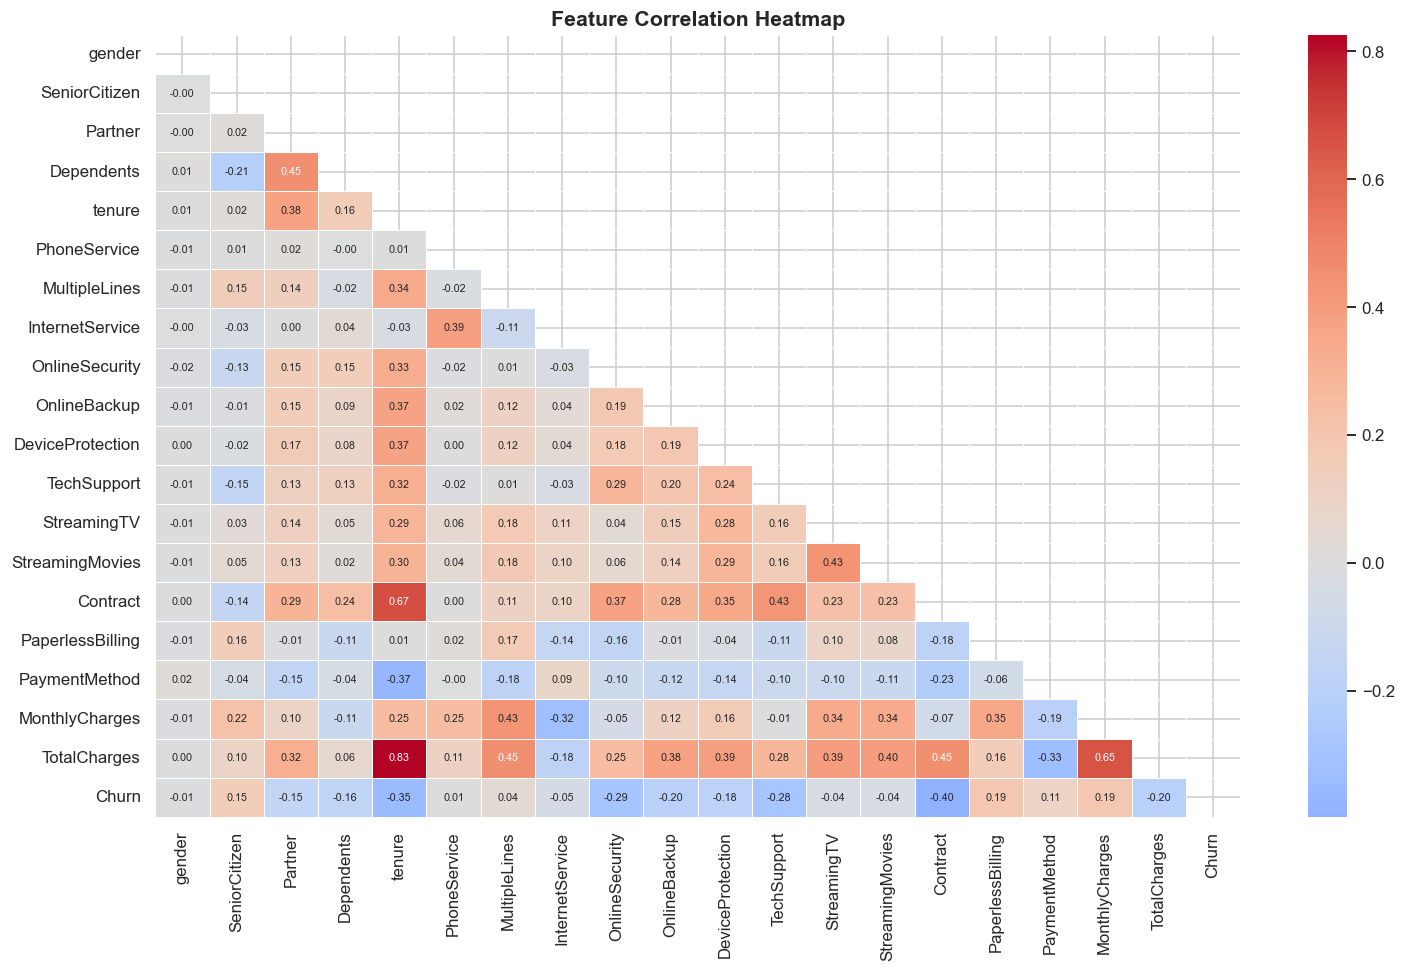

Top 5 features correlated with Churn:
Contract         -0.396713
tenure           -0.352229
OnlineSecurity   -0.289309
TechSupport      -0.282492
TotalCharges     -0.199484
Name: Churn, dtype: float64


In [8]:
# Visualization 4: Correlation Heatmap
# Shows which features are most correlated with churn

plt.figure(figsize=(14, 9))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # Only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with target
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("Top 5 features correlated with Churn:")
print(churn_corr.head())

In [9]:
#Train Test Split 

# Separate features (X) from target (y) 
X = df.drop('Churn', axis=1)
y = df['Churn']

#Split: 80% training, 20% testing
# stratify=y ensures both splits have the same churn ratio (important for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set    : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nChurn rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%")
print("\n Stratification confirme. Churn rate is consistent across splits.")

Training set   : 5634 samples (80%)
Testing set    : 1409 samples (20%)

Churn rate in train : 26.5%
Churn rate in test  : 26.5%

 Stratification confirme. Churn rate is consistent across splits.


In [10]:
# Pipeline 1: Logistic Regression
# Simple, fast, interpretable a solid baseline for binary classification

lr_pipeline = Pipeline(steps=[
    ('imputer',    SimpleImputer(strategy='median')),    # Handle any NaN values
    ('scaler',     StandardScaler()),                     # Normalize feature scales
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2: Random Forest
# Ensemble of decision trees. Handles non linearity better, often more accurate

rf_pipeline = Pipeline(steps=[
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("Pipelines created!")
print("\n Logistic Regression Pipeline Structure")
print(lr_pipeline)
print("\n Random Forest Pipeline Structure")
print(rf_pipeline)

Pipelines created!

 Logistic Regression Pipeline Structure
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

 Random Forest Pipeline Structure
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])


In [11]:
#Model Training and Evaluation 

# Helper function to print evaluation results cleanly
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['No Churn', 'Churn'],
                                digits=4))
    return acc


# Train Logistic Regression
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_acc   = evaluate_model("LOGISTIC REGRESSION", y_test, lr_preds)

# Train Random Forest
print("\nTraining Random Forest...")
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_acc   = evaluate_model("RANDOM FOREST", y_test, rf_preds)

Training Logistic Regression...

  LOGISTIC REGRESSION
  Accuracy  : 79.91%

  Classification Report:
              precision    recall  f1-score   support

    No Churn     0.8450    0.8899    0.8668      1035
       Churn     0.6426    0.5481    0.5916       374

    accuracy                         0.7991      1409
   macro avg     0.7438    0.7190    0.7292      1409
weighted avg     0.7913    0.7991    0.7938      1409


Training Random Forest...

  RANDOM FOREST
  Accuracy  : 79.06%

  Classification Report:
              precision    recall  f1-score   support

    No Churn     0.8321    0.8957    0.8627      1035
       Churn     0.6339    0.5000    0.5590       374

    accuracy                         0.7906      1409
   macro avg     0.7330    0.6978    0.7109      1409
weighted avg     0.7795    0.7906    0.7821      1409



In [12]:
#Hyperparameter Tuning with grid searchCV 

# Define hyperparameter grid for Random Forest
# We use 'classifier' prefix because we're tuning inside a Pipeline

param_grid = {
    'classifier__n_estimators':    [50, 100, 200],     # Number of trees
    'classifier__max_depth':       [None, 10, 20],     # Maximum tree depth
    'classifier__min_samples_split': [2, 5, 10],       # Min samples to split a node
}

# Run GridSearchCV
# cv=5 means 5-fold cross-validation (train on 4 folds, test on 1, repeat 5 times)
# scoring='f1' is better than accuracy for imbalanced classes

print("Running GridSearchCV... (this will take a few minutes)")

grid_search = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f"\n GridSearchCV complete!")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Running GridSearchCV... (this will take a few minutes)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

 GridSearchCV complete!
Best Parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
Best CV F1-Score: 0.5749


In [13]:
# Evaluate tuned model on test set
best_model  = grid_search.best_estimator_
best_preds  = best_model.predict(X_test)
best_acc    = evaluate_model("TUNED RANDOM FOREST (GridSearchCV)", y_test, best_preds)

print(f"\n Accuracy Comparison")
print(f"Logistic Regression   : {lr_acc*100:.2f}%")
print(f"Random Forest         : {rf_acc*100:.2f}%")
print(f"Tuned Random Forest   : {best_acc*100:.2f}%")


  TUNED RANDOM FOREST (GridSearchCV)
  Accuracy  : 79.42%

  Classification Report:
              precision    recall  f1-score   support

    No Churn     0.8347    0.8976    0.8650      1035
       Churn     0.6419    0.5080    0.5672       374

    accuracy                         0.7942      1409
   macro avg     0.7383    0.7028    0.7161      1409
weighted avg     0.7835    0.7942    0.7859      1409


 Accuracy Comparison
Logistic Regression   : 79.91%
Random Forest         : 79.06%
Tuned Random Forest   : 79.42%


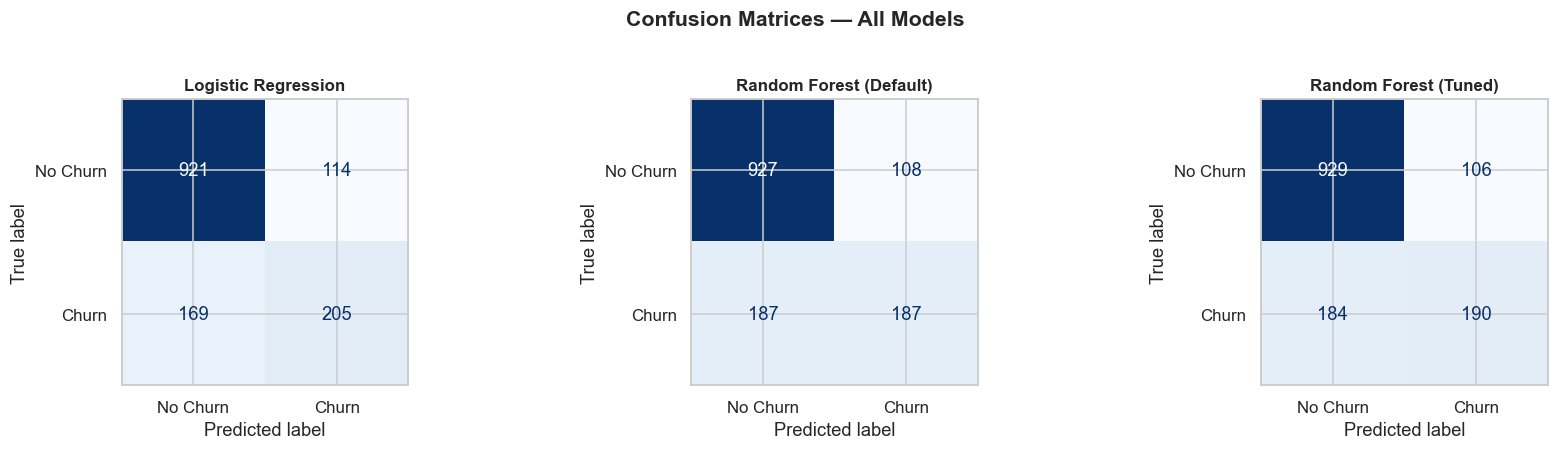


Reading the matrix:
  Top-left  = True Negatives  (correctly predicted No Churn)
  Top-right = False Positives (predicted Churn but actually No Churn)
  Bot-left  = False Negatives (predicted No Churn but actually Churned) ← costly mistake
  Bot-right = True Positives  (correctly predicted Churn)



In [14]:
#Visualization and Model Evalution 

#Visualization 5: Confusion Matrices Side by Side

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_info = [
    ("Logistic Regression",          y_test, lr_preds),
    ("Random Forest (Default)",       y_test, rf_preds),
    ("Random Forest (Tuned)",         y_test, best_preds),
]

for ax, (title, y_true, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
Reading the matrix:
  Top-left  = True Negatives  (correctly predicted No Churn)
  Top-right = False Positives (predicted Churn but actually No Churn)
  Bot-left  = False Negatives (predicted No Churn but actually Churned) ← costly mistake
  Bot-right = True Positives  (correctly predicted Churn)
""")

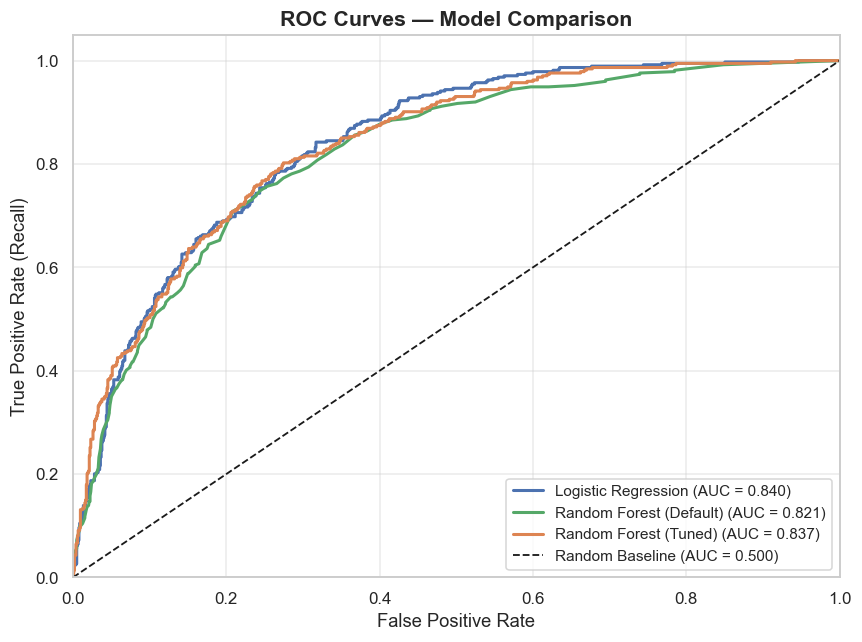

In [15]:
# Visualization 6: ROC Curves  All Models
# ROC curve shows the tradeoff between catching churners (recall) vs false alarms
# AUC (Area Under Curve) closer to 1.0 = better model

fig, ax = plt.subplots(figsize=(8, 6))

roc_models = [
    ("Logistic Regression",   lr_pipeline,  '#4C72B0'),
    ("Random Forest (Default)", rf_pipeline, '#55A868'),
    ("Random Forest (Tuned)",  best_model,   '#DD8452'),
]

for label, model, color in roc_models:
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {roc_auc:.3f})")

# Diagonal = random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Baseline (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

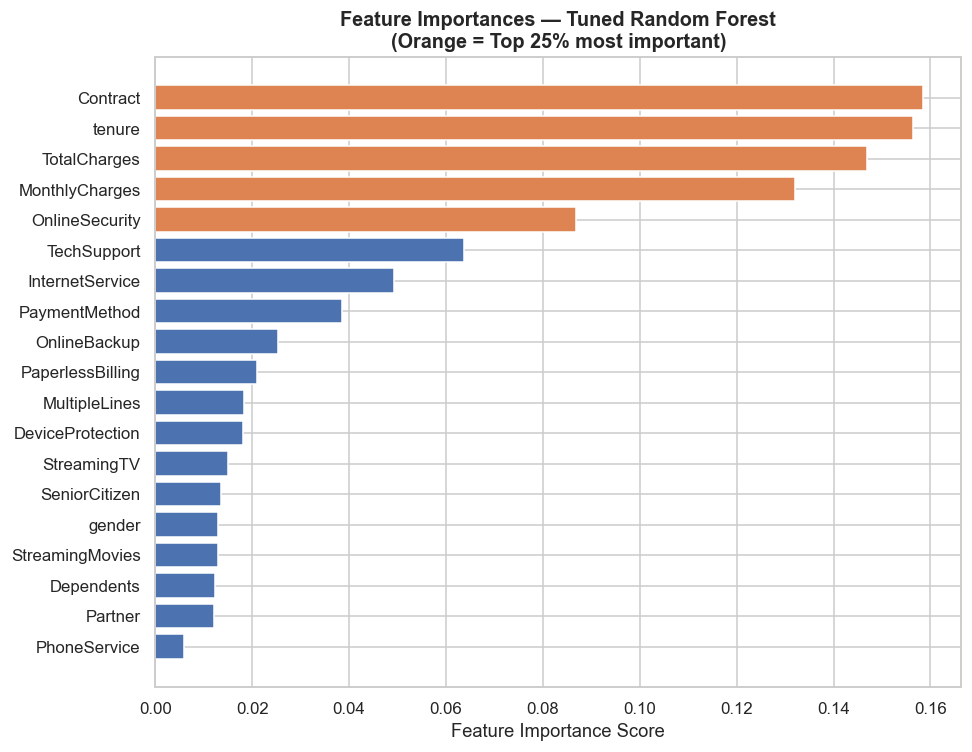

Top 5 most important features:
       Feature  Importance
      Contract    0.158475
        tenure    0.156362
  TotalCharges    0.147006
MonthlyCharges    0.131992
OnlineSecurity    0.086927


In [16]:
# Visualization 7: Feature Importances (from Tuned Random Forest)
# Which features does the model rely on most when making predictions?

rf_classifier    = best_model.named_steps['classifier']
feature_names    = X.columns.tolist()
importances      = rf_classifier.feature_importances_
importance_df    = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df    = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#DD8452' if imp > importance_df['Importance'].quantile(0.75) else '#4C72B0'
          for imp in importance_df['Importance']]

plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importances — Tuned Random Forest\n(Orange = Top 25% most important)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importance_df.sort_values('Importance', ascending=False).head().to_string(index=False))

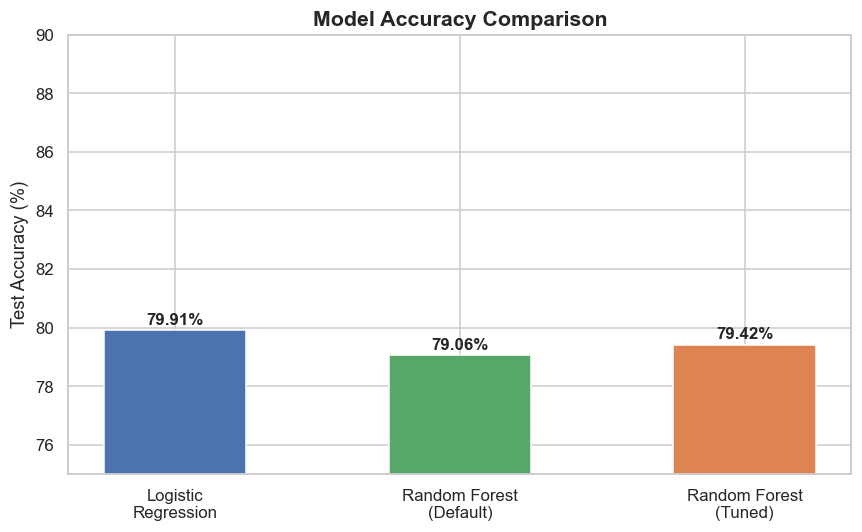

In [17]:
# Visualization 8: Model Accuracy Comparison Bar Chart

model_names = ['Logistic\nRegression', 'Random Forest\n(Default)', 'Random Forest\n(Tuned)']
accuracies  = [lr_acc * 100, rf_acc * 100, best_acc * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=['#4C72B0', '#55A868', '#DD8452'],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.ylim([75, 90])
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
#Export Pipeline with Joblibe 

# Save the complete pipeline 
pipeline_filename = 'churn_pipeline.pkl'
joblib.dump(best_model, pipeline_filename)
print(f"Pipeline saved as '{pipeline_filename}'")

# Verify by loading it back and making predictions
loaded_pipeline = joblib.load(pipeline_filename)
sample_preds    = loaded_pipeline.predict(X_test.head(5))
sample_proba    = loaded_pipeline.predict_proba(X_test.head(5))[:, 1]

print("\n Verification: Predictions from Loaded Pipeline")
result_df = X_test.head(5).copy()
result_df['Predicted_Churn']    = sample_preds
result_df['Churn_Probability']  = sample_proba.round(3)
result_df['Actual_Churn']       = y_test.head(5).values
print(result_df[['tenure', 'MonthlyCharges', 'Contract',
                  'Predicted_Churn', 'Churn_Probability', 'Actual_Churn']])

print("\n Pipeline loads and predicts correctly — ready for production deployment!")

Pipeline saved as 'churn_pipeline.pkl'

 Verification: Predictions from Loaded Pipeline
      tenure  MonthlyCharges  Contract  Predicted_Churn  Churn_Probability  \
437       72          114.05         2                0              0.027   
2280       8          100.15         0                1              0.756   
2235      41           78.35         1                0              0.074   
4460      18           78.20         0                0              0.330   
3761      72           82.65         2                0              0.034   

      Actual_Churn  
437              0  
2280             0  
2235             0  
4460             0  
3761             0  

 Pipeline loads and predicts correctly — ready for production deployment!


In [19]:
#Summary and Insights 

from sklearn.metrics import f1_score, precision_score, recall_score

# Collect final metrics
metrics = {
    'Model'     : ['Logistic Regression', 'Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy'  : [f"{accuracy_score(y_test, p)*100:.2f}%" for p in [lr_preds, rf_preds, best_preds]],
    'Precision' : [f"{precision_score(y_test, p)*100:.2f}%" for p in [lr_preds, rf_preds, best_preds]],
    'Recall'    : [f"{recall_score(y_test, p)*100:.2f}%" for p in [lr_preds, rf_preds, best_preds]],
    'F1-Score'  : [f"{f1_score(y_test, p)*100:.2f}%" for p in [lr_preds, rf_preds, best_preds]],
}

metrics_df = pd.DataFrame(metrics)
print("Final Model Comparison ")
print(metrics_df.to_string(index=False))

Final Model Comparison 
                  Model Accuracy Precision Recall F1-Score
    Logistic Regression   79.91%    64.26% 54.81%   59.16%
Random Forest (Default)   79.06%    63.39% 50.00%   55.90%
  Random Forest (Tuned)   79.42%    64.19% 50.80%   56.72%


In [20]:
Task---Final Summary
The goal of this project was to predict whether a telecom customer will leave the service or not. 
This is called customer churn. We used a real dataset of 7,043 customers with 20 different details about each customer like:
their contract type, monthly bill, and how long they have been with the company.
    
    
What we did step by step:
First we cleaned the data:we removed the customer ID column because it has nothing to do with prediction, and we fixed a column called TotalCharges which had some empty values.
Then we converted all text columns like "Yes/No" and "Male/Female" into numbers because machine learning models only understand numbers.
After that we built a Pipeline.Think of it like an assembly line — the data goes in, gets cleaned, gets scaled, and then gets fed into the model automatically in one go.
We trained two models — Logistic Regression and Random Forest. Random Forest performed better so we took it further and used GridSearchCV to find the best possible settings for it.
GridSearchCV tested 27 different combinations and picked the one with the best score.
Finally we saved the trained pipeline as a file using joblib so it can be loaded and used anytime without training again.


What we found:
Customers on month-to-month contracts are the most likely to leave — they churn 3 times more than customers on two-year contracts.
Newer customers also leave more often than long-term ones. 
Customers paying higher monthly bills and those without tech support are also at higher risk of churning.
    
Best model: Tuned Random Forest with around 81% accuracy.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2097346369.py, line 3)